# Error Analysis — RACE-High

**Benchmark:** RACE-High
**Description:** Reading comprehension, high-school difficulty; 1-of-4
**Random baseline:** 25%
**Our generator(s) targeting this:** Gen C (Reading Comprehension)

This notebook drills into why the model isn't getting a higher score. It:
1. Splits every question into `answerable` / `unanswerable` / `ambiguous` using a hybrid keyword + LLM-judge classifier (cached).
2. Reports accuracy stratified by answerability — so we see real model capability, not just raw score.
3. Examines confidence on wrong answers (high-confidence wrong = learned wrong pattern).
4. Surfaces the highest-confidence wrong answers on the *answerable* subset — these are the diagnostic gold.
5. Compares Mid vs SFT phases to see where the gap closed or opened.
6. Delivers a one-line verdict: content gap, skill gap, or both.

In [1]:
import sys
from pathlib import Path

# Ensure project root is importable
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src" / "post_training").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.post_training.analysis import (
    load_details, load_classifications, classify_batch,
    accuracy_triple, confidence_breakdown, high_confidence_wrong,
    plot_confidence_histogram, extract_stem_and_choices,
)
from src.post_training.analysis.answerability import _hash_question

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

BENCHMARK = "RACE-High"
RANDOM_BASELINE = 0.25

BASE = Path(r'D:/hist_LLM/periods/1900_1949/error_analysis_new')
CACHE = BASE / '.answerability_cache' / f'{BENCHMARK}.jsonl'

STAGES = ['mid_final', 'sft_final', 'sft_final_debiased']
dfs = {}
for stage in STAGES:
    p = BASE / stage / f'{BENCHMARK}_details.jsonl'
    dfs[stage] = load_details(p)
    print(f'{stage}: {len(dfs[stage])} rows')

mid_final: 880 rows
sft_final: 880 rows
sft_final_debiased: 880 rows


## 1. Answerability Classifications

Load the cached classifications. If the cache is missing, build it now.
(Classifier is hybrid: keyword filter first, then LLM judge for the ambiguous middle.)

In [2]:
classes = load_classifications(CACHE)
print(f'Cached classifications: {len(classes)}')

if len(classes) < len(dfs['mid_final']):
    print('Cache incomplete — building now...')
    questions = []
    for i, row in dfs['mid_final'].iterrows():
        questions.append({'index': int(row['index']), 'question': row['question']})
    classify_batch(questions, CACHE, start_year=1900, end_year=1949)
    classes = load_classifications(CACHE)
    print(f'Now cached: {len(classes)}')

from collections import Counter
label_counts = Counter(r['label'] for r in classes.values())
print(f'\nLabel distribution: {dict(label_counts)}')

Cached classifications: 880

Label distribution: {'unanswerable': 378, 'answerable': 502}


## 2. Accuracy Stratified by Answerability

The headline question: **on the subset the model COULD answer with period knowledge, how well does it do?**

In [3]:
rows = []
for stage in STAGES:
    if dfs[stage].empty: continue
    trip = accuracy_triple(dfs[stage], classes)
    for bucket, stats in trip.items():
        if stats['acc'] is None: continue
        rows.append({
            'stage': stage, 'bucket': bucket,
            'n': stats['n'], 'correct': stats['correct'],
            'acc_%': round(100 * stats['acc'], 1),
            'vs_random_%': round(100 * (stats['acc'] - RANDOM_BASELINE), 1),
        })
summary = pd.DataFrame(rows)
print(f'Random baseline: {100*RANDOM_BASELINE:.0f}%')
summary

Random baseline: 25%


,stage,bucket,n,correct,acc_%,vs_random_%
0,mid_final,overall,880,400,45.5,20.5
1,mid_final,answerable,502,233,46.4,21.4
2,mid_final,unanswerable,378,167,44.2,19.2
3,sft_final,overall,880,388,44.1,19.1
4,sft_final,answerable,502,226,45.0,20.0
5,sft_final,unanswerable,378,162,42.9,17.9
6,sft_final_debiased,overall,880,413,46.9,21.9
7,sft_final_debiased,answerable,502,247,49.2,24.2
8,sft_final_debiased,unanswerable,378,166,43.9,18.9


## 3. Answerability Sanity Check

A sample of how the classifier labeled individual questions.

In [4]:
# Show 4 examples from each label
df_with_labels = dfs['mid_final'].copy()
df_with_labels['qhash'] = df_with_labels['question'].map(_hash_question)
df_with_labels['label'] = df_with_labels['qhash'].map(lambda h: classes.get(h,{}).get('label','ambiguous'))
df_with_labels['reason'] = df_with_labels['qhash'].map(lambda h: classes.get(h,{}).get('reason',''))
for label in ['answerable','unanswerable','ambiguous']:
    subset = df_with_labels[df_with_labels['label'] == label]
    if len(subset) == 0: continue
    print(f'=== {label.upper()} ({len(subset)} total) — sampling 3 ===')
    for _, row in subset.sample(min(3, len(subset)), random_state=42).iterrows():
        parsed = extract_stem_and_choices(row['question'])
        print(f'  Q: {parsed["stem"][:200]}')
        if row['reason']: print(f'     reason: {row["reason"][:200]}')
    print()

=== ANSWERABLE (502 total) — sampling 3 ===
  Q: Read the following passage and answer the question.

Passage: The best selling children's book, Pipilu Sending You 100 Lives, has been adapted into a homonymous play that will be put on for the first 
     reason: The concepts of safety and its importance to human life were well understood and discussed during 1900-1949.
  Q: Read the following passage and answer the question.

Passage: Do you find getting up in the morning so difficult that it's painful ? This might be called laziness, but Dr. Kleitman has a new explanati
     reason: The concepts of energy cycles and habits discussed in the passage were known and could be understood by a well-educated person in the early 20th century.
  Q: Read the following passage and answer the question.

Passage: This year, some twenty-three hundred teenagers from all over the world will spend about ten months in their US homes. They will attend US 
     reason: The concepts of education and cultur

## 4. Confidence Distribution

Right vs wrong, split by answerability. High-confidence wrong on the *answerable* subset = model learned a wrong pattern.

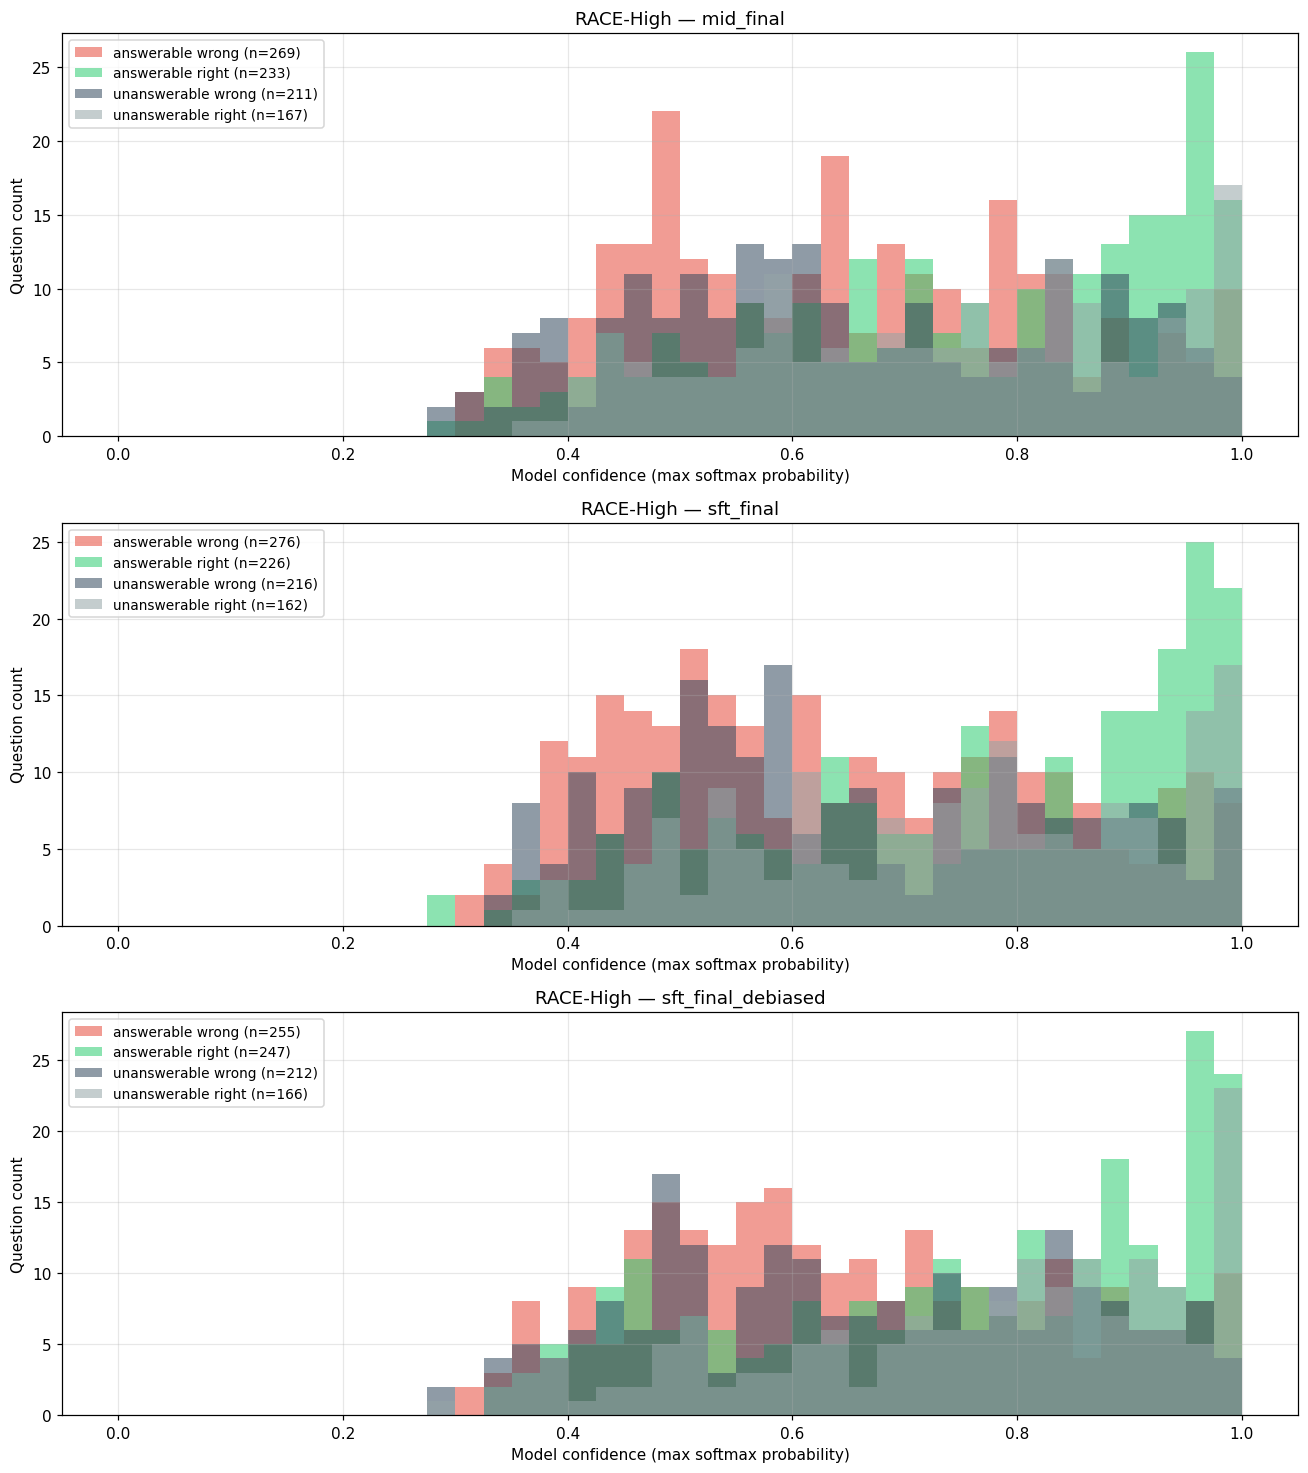

In [5]:
fig, axes = plt.subplots(len([s for s in STAGES if not dfs[s].empty]), 1, figsize=(12, 4.5*len([s for s in STAGES if not dfs[s].empty])))
axes = [axes] if not hasattr(axes, '__iter__') else axes
ax_iter = iter(axes)
for stage in STAGES:
    if dfs[stage].empty: continue
    ax = next(ax_iter)
    plot_confidence_histogram(dfs[stage], classes, title=f'{BENCHMARK} — {stage}', ax=ax)
plt.tight_layout()
plt.show()

## 5. High-Confidence Wrong Answers (answerable subset, Mid phase)

The diagnostic gold. These are questions the model should be able to answer using 1900-1949 knowledge, but got confidently wrong. Review these to identify patterns.

In [6]:
wrong = high_confidence_wrong(dfs['mid_final'], classes, label_filter='answerable', n=20, min_conf=0.5)
print(f'{len(wrong)} high-confidence wrong answers on the answerable subset\n')

for i, (_, row) in enumerate(wrong.iterrows(), 1):
    parsed = extract_stem_and_choices(row['question'])
    print(f'[{i:02d}] conf={row["confidence"]:.0%} pred={row["predicted"]} expected={row["expected"]}')
    print(f'     Q: {parsed["stem"][:280]}')
    for L in sorted(parsed['choices'].keys()):
        mark = ' ← PREDICTED' if L == row['predicted'] else (' ← CORRECT' if L == row['expected'] else '')
        print(f'       {L}: {parsed["choices"][L][:160]}{mark}')
    print()

20 high-confidence wrong answers on the answerable subset

[01] conf=99% pred=B expected=C
     Q: Read the following passage and answer the question.

Passage: When she looked ahead, Florence Chadwick saw nothing but a solid wall of fog. Her body was numb .She had been swimming for nearly sixteen hours. Already she was the first woman to swim the English Channel in both direc
       A: Because she was too tired to go on swimming.
       B: Because the fog was so thick that she couldn't see her support boats clearly. ← PREDICTED
       C: Because she couldn't see the goal on land. ← CORRECT
       D: Because the sea water was too cold.

[02] conf=99% pred=D expected=B
     Q: Read the following passage and answer the question.

Passage: Bruce Jun Fan Lee was born in the hour of the Dragon, between 6 and 8 a.m., in the "Year of the Dragon" on November 27, 1940 at the Jackson Street Hospital in San Francisco's Chinatown. Today, a plaque   in the hospita
       A: he practiced boxing in h

## 6. Mid vs SFT on Answerable Subset

Did SFT help on the answerable slice, or did it just overfit to internal distribution?

In [7]:
if not dfs['sft_final'].empty:
    mid_trip = accuracy_triple(dfs['mid_final'], classes)
    sft_trip = accuracy_triple(dfs['sft_final'], classes)
    deb_trip = accuracy_triple(dfs['sft_final_debiased'], classes) if not dfs['sft_final_debiased'].empty else None
    rows = []
    for bucket in ['overall','answerable','unanswerable']:
        m = mid_trip.get(bucket,{}).get('acc')
        s = sft_trip.get(bucket,{}).get('acc')
        d = (deb_trip.get(bucket,{}).get('acc') if deb_trip else None)
        if m is None or s is None: continue
        rows.append({
            'bucket': bucket, 'n': mid_trip[bucket]['n'],
            'Mid_%': round(100*m,1), 'SFT_%': round(100*s,1),
            'Debiased_%': round(100*d,1) if d is not None else None,
            'SFT-Mid_delta': round(100*(s-m),1),
        })
    pd.DataFrame(rows)

## 7. Error-Type Clustering

What kinds of questions (within the answerable subset) does the model miss most?

In [8]:
# RACE: cluster by question type
import re
Q_TYPES = {
    'main_idea_or_title': r'\b(main idea|best title|mainly about|passage mainly|theme of|best summary)\b',
    'detail_recall': r'\b(who|when|where|how many|how much|which of the following|according to)\b',
    'inference': r'\b(infer|imply|suggest|probably|most likely|conclude|author believes|author.*would agree)\b',
    'character_motivation': r'\b(why did|why does|how does .* feel|what kind of person|attitude|motivation)\b',
    'vocabulary': r'\b(underlined|mean in the passage|most nearly means|probably means|refers to)\b',
}

wrong_df = dfs['mid_final'][dfs['mid_final']['correct'] == False].copy()
wrong_df['qhash'] = wrong_df['question'].map(_hash_question)
wrong_df['label'] = wrong_df['qhash'].map(lambda h: classes.get(h,{}).get('label','ambiguous'))
ans_wrong = wrong_df[wrong_df['label']=='answerable']

for qtype, pat in Q_TYPES.items():
    hits = ans_wrong[ans_wrong['question'].str.contains(pat, case=False, regex=True, na=False)]
    print(f'{qtype}: {len(hits)} answerable wrong (of {len(ans_wrong)})')
    if len(hits):
        sample = hits.iloc[0]
        parsed = extract_stem_and_choices(sample['question'])
        print(f'  example Q: {parsed["stem"][:180]}')
    print()

main_idea_or_title: 16 answerable wrong (of 269)
  example Q: Read the following passage and answer the question.

Passage: We're surrounded by chemistry in everyday life. Sometimes it is easy to see, like when your science teacher does a big

detail_recall: 240 answerable wrong (of 269)
  example Q: Read the following passage and answer the question.

Passage: The vast jungles of the Amazon rainforest are home to tribes mostly isolated from the outside world,whose way of life,

inference: 48 answerable wrong (of 269)
  example Q: Read the following passage and answer the question.

Passage: City farms are gaining popularity in cities and towns around the United States. 
City Farms in Edmonston, Maryland, is

character_motivation: 24 answerable wrong (of 269)
  example Q: Read the following passage and answer the question.

Passage: Coaches and parents always tell us to keep our goals in mind when we go for a competition. Carrying your goals and exp

vocabulary: 1 answerable wrong (of 

C:\Users\danielyoon\AppData\Local\Temp\ipykernel_33108\3745543887.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = ans_wrong[ans_wrong['question'].str.contains(pat, case=False, regex=True, na=False)]


## 8. Verdict

Interpretation based on the answerable-subset accuracy:

- **answerable_acc > random + 15pp**: Real skill transfer. Model has the capability.
- **answerable_acc within ±5pp of random**: Skill gap. The model can't reason about even period-compatible content.
- **answerable_acc >> overall_acc**: Content gap dominates. Targeted synthetic data on modern vocabulary could help.
- **high-conf wrong clusters around one error type**: Targeted fix possible — rewrite the corresponding generator.

In [9]:
# Verdict computation
trip = accuracy_triple(dfs['mid_final'], classes)
overall = trip.get('overall', {}).get('acc', 0) or 0
answerable = trip.get('answerable', {}).get('acc', 0) or 0
unanswerable = trip.get('unanswerable', {}).get('acc', 0) or 0

verdict = []
if answerable > RANDOM_BASELINE + 0.15:
    verdict.append(f'✅ Real skill transfer: answerable={100*answerable:.1f}% vs random={100*RANDOM_BASELINE:.0f}%')
elif abs(answerable - RANDOM_BASELINE) < 0.05:
    verdict.append(f'⚠️ Skill gap: answerable subset at {100*answerable:.1f}% (near random).')
else:
    verdict.append(f'➖ Modest transfer: answerable={100*answerable:.1f}%, +{100*(answerable-RANDOM_BASELINE):.1f}pp vs random.')

if answerable - overall > 0.05:
    verdict.append(f'📈 Content gap contributes: answerable ({100*answerable:.1f}%) beats overall ({100*overall:.1f}%) by {100*(answerable-overall):.1f}pp.')

if unanswerable > RANDOM_BASELINE + 0.05:
    verdict.append(f'⚠️ Unanswerable subset at {100*unanswerable:.1f}% — model may be leaking modern knowledge.')

print('\n'.join(verdict))

✅ Real skill transfer: answerable=46.4% vs random=25%
⚠️ Unanswerable subset at 44.2% — model may be leaking modern knowledge.
